In [ ]:
pip install pandas matplotlib seaborn scikit-learn xlrd openpyxl

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# Load the data
file = './sample_-_superstore.xls'
df = pd.read_excel(file, sheet_name='Orders', parse_dates=['Order Date'])

display(df.head())
print(df.shape)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


(10194, 21)


### Data Quality Check
- Missing values
- Duplicate orders
- Logical consistency

In [3]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [4]:
print(df.duplicated().sum())

0


In [5]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,10194.0,228.225854,619.906839,0.444,17.2200,53.91,209.500000,22638.480
Quantity,10194.0,3.791838,2.228317,1.000,2.0000,3.00,5.000000,14.000
Discount,10194.0,0.155385,0.206249,0.000,0.0000,0.20,0.200000,0.800
Profit,10194.0,28.673417,232.465115,-6599.978,1.7608,8.69,29.297925,8399.976


In [6]:
df.describe(include=object)

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194
unique,5111,4,804,800,3,2,542,59,654,4,1862,3,17,1849
top,US-2026-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035,West,FUR-FU-10004270,Office Supplies,Binders,Staples
freq,14,6120,41,41,5281,9994,915,2001,263,3253,20,6128,1548,50


There are no missing values or duplicates values in the dataset. There are no data errors (e.g., negative or zero quantities). All categorical features are having number of classes.

### Exploratory Data Analysis
- YoY growth rates
- Quarterly sales and profit trend
- Profitability by category
- Region-wise performance
- Impact of high discounts on profit

In [7]:
# Calculate key metrics
total_revenue   = df['Sales'].sum()
total_profit    = df['Profit'].sum()
profit_margin   = total_profit / total_revenue * 100
total_orders    = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
aov             = df.groupby('Order ID')['Sales'].sum().mean()

print("Superstore Sales Summary 2023 - 2026")
print(f'Total Revenue:\t\t${total_revenue:,.2f}')
print(f'Total Profit:\t\t${total_profit:,.2f}')
print(f'Profit Margin:\t\t{profit_margin:.2f}%')
print(f'Total Orders:\t\t{total_orders:,}')
print(f'Total Customers:\t{total_customers:,}')
print(f'Average Order Value:\t${aov:,.2f}')

Superstore Sales Summary 2023 - 2026
Total Revenue:		$2,326,534.35
Total Profit:		$292,296.81
Profit Margin:		12.56%
Total Orders:		5,111
Total Customers:	804
Average Order Value:	$455.20


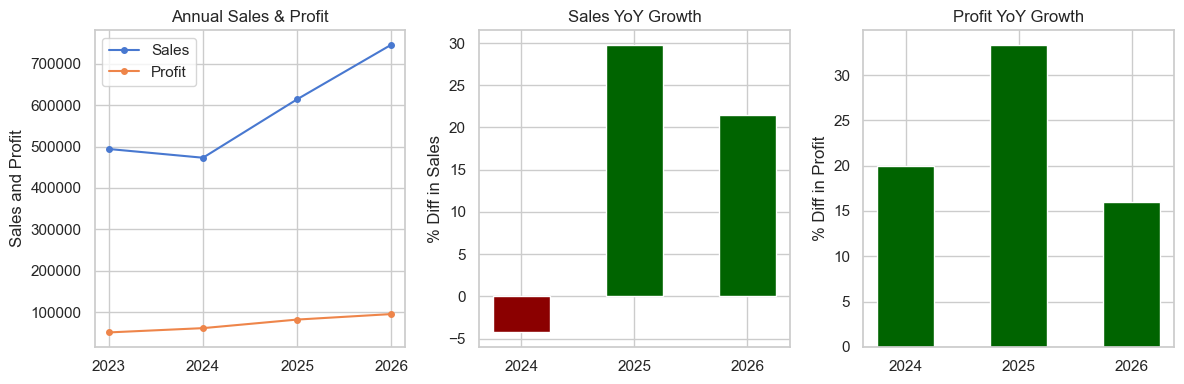

,Year,Sales,Profit,Sales_Diff,Profit_Diff
0,2023,494040.2121,51684.2957,NaN,NaN
1,2024,472993.0310,62020.9695,-4.260216,19.999641
2,2025,613933.5800,82665.2018,29.797595,33.285891
3,2026,745567.5312,95926.3476,21.441074,16.041993


In [8]:
# Calculate YoY Growth
df['Year'] = df['Order Date'].dt.year

annual = df.groupby('Year').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
).reset_index()
annual['Sales_Diff'] = annual['Sales'].pct_change() * 100
annual['Profit_Diff'] = annual['Profit'].pct_change() * 100

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(annual['Year'].astype(str), annual['Sales'], marker='o', markersize=4)
axes[0].plot(annual['Year'].astype(str), annual['Profit'], marker='o', markersize=4)
axes[0].set_title('Annual Sales & Profit')
axes[0].set_ylabel('Sales and Profit')
axes[0].legend(['Sales', 'Profit'])

yoy_sales = annual.dropna(subset=['Sales_Diff'])
colors = ['darkgreen' if v > 0 else 'darkred' for v in yoy_sales['Sales_Diff']]
axes[1].bar(yoy_sales['Year'].astype(str), yoy_sales['Sales_Diff'],
            color=colors, width=0.5)
axes[1].set_title('Sales YoY Growth')
axes[1].set_ylabel('% Diff in Sales')

yoy_profit = annual.dropna(subset=['Profit_Diff'])
colors = ['darkgreen' if v > 0 else 'darkred'for v in yoy_profit['Profit_Diff']]
axes[2].bar(yoy_profit['Year'].astype(str), yoy_profit['Profit_Diff'],
            color=colors, width=0.5)
axes[2].set_title('Profit YoY Growth')
axes[2].set_ylabel('% Diff in Profit')

plt.tight_layout()
plt.show()

display(annual[['Year', 'Sales', 'Profit', 'Sales_Diff','Profit_Diff']])

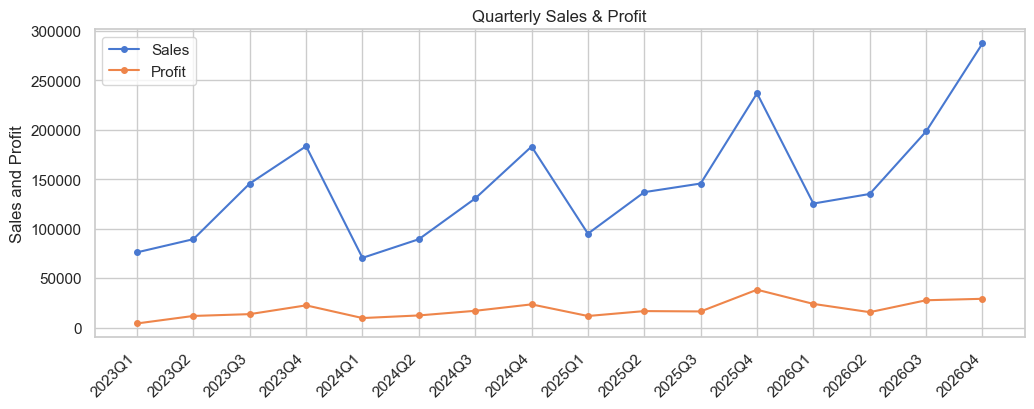

In [9]:
# Aggregate quarterly sales and profit
df['year_quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

quarterly = df.groupby('year_quarter').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

plt.figure(figsize=(12, 4))
plt.plot(quarterly['year_quarter'], quarterly['Sales'], marker='o', markersize=4, label='Sales')
plt.plot(quarterly['year_quarter'], quarterly['Profit'], marker='o', markersize=4, label='Profit')
plt.title('Quarterly Sales & Profit')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Sales and Profit')
plt.legend()
plt.show()

Strong Q4 seasonality surges are observed across all years.

In [10]:
# Performance across major product categories
category = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean')
).reset_index()
category['Profit_Margin'] = (category['Total_Profit'] / category['Total_Sales']) * 100

display(category.sort_values(by='Total_Sales', ascending=False))

,Category,Total_Sales,Total_Profit,Avg_Discount,Profit_Margin
2,Technology,839893.2790,146543.3756,0.131475,17.447857
0,Furniture,754747.7613,19729.9956,0.172962,2.614118
1,Office Supplies,731893.3140,126023.4434,0.156348,17.218827


Furniture category generates high sales value but low profit margin.
- Potential cause: Furniture has the highest average discount among all categories.

In [11]:
# Performance across regions
region = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()
region['Profit_Margin'] = (region['Total_Profit'] / region['Total_Sales']) * 100

display(region.sort_values(by='Total_Profit', ascending=False))

,Region,Total_Sales,Total_Profit,Profit_Margin
3,West,739813.6085,110798.8170,14.976585
1,East,691828.1680,94883.2603,13.714859
2,South,391721.9050,46749.4303,11.934342
0,Central,503170.6728,39865.3070,7.922820


Despite outperforming the South region by over $111K in sales, the Central region yielded the lowest profit margin.

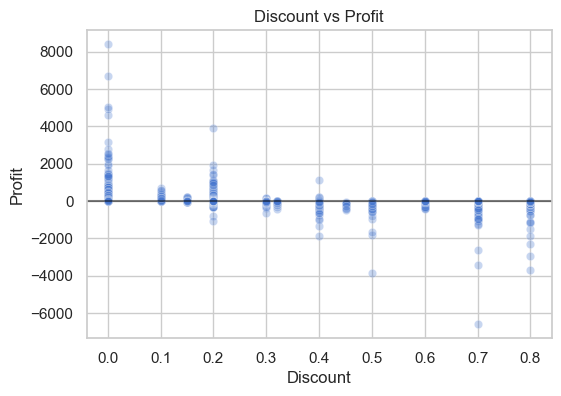

In [12]:
# Impact of high discounts on profit
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.3)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.show()

Discounts >20% lead to losses.

### RFM Segmentation

In [13]:
# Set reference date as day after last order
reference_date = df['Order Date'].max() + dt.timedelta(days=1)

# Build RFM features
rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
). reset_index()

display(rfm.head())
display(rfm.describe())

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


,Recency,Frequency,Monetary
count,804.000000,804.000000,804.000000
mean,147.016169,6.364428,2893.699446
std,185.551511,2.660121,2653.778471
min,1.000000,1.000000,4.833000
25%,30.000000,5.000000,1084.538000
50%,76.000000,6.000000,2243.392000
75%,181.750000,8.000000,3790.812100
max,1166.000000,17.000000,25043.050000


In [14]:
# Handle outliers and scale (log-transform and standardization)
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

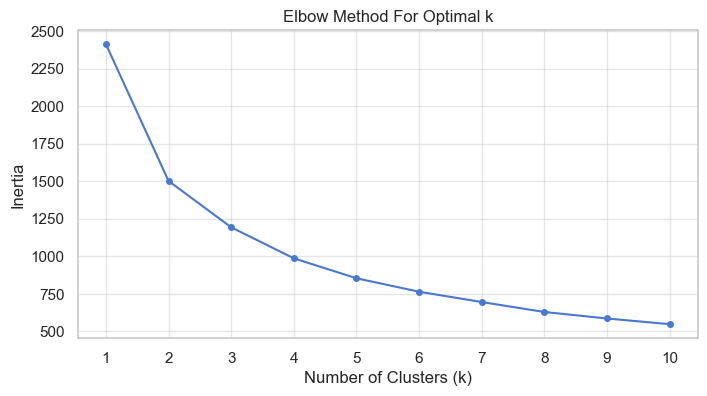

In [15]:
# Find the right number of clusters
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', markersize=4)
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, linestyle='-', alpha=0.5)
plt.show()

The optimal number of customer segments is k=3 or k=4.

In [16]:
# Run K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'] = rfm['Cluster'].astype(str)

# Get the average profile of each segment
summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
display(summary)

,Recency,Frequency,Monetary
Cluster,,,
0,96.7,8.9,4875.3
1,318.3,2.5,412.5
2,19.4,6.8,2687.0
3,233.8,5.0,2017.0


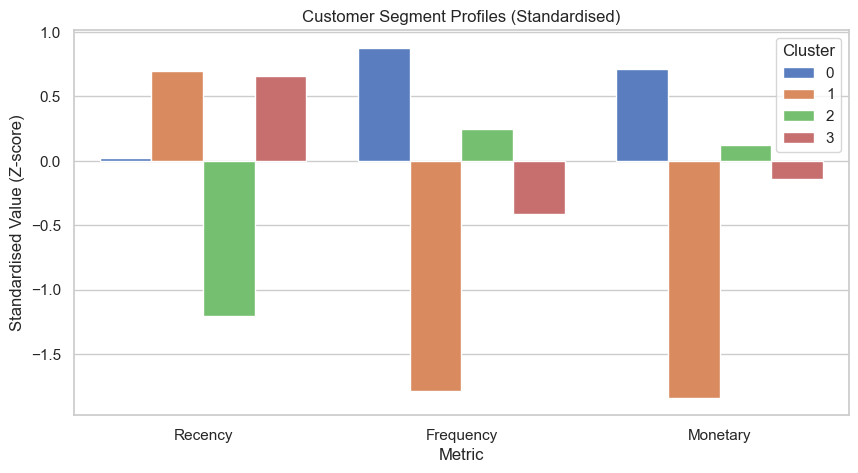

In [17]:
# Interpret the clusters
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns= ['Recency', 'Frequency', 'Monetary'])

rfm_scaled_df['Cluster'] = rfm['Cluster'].values

cluster_profile = rfm_scaled_df.groupby('Cluster').mean().reset_index()

rfm_melt = cluster_profile.melt(id_vars='Cluster', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 5))
sns.barplot(data=rfm_melt, x='Metric', y='Value', hue='Cluster')
plt.title('Customer Segment Profiles (Standardised)')
plt.ylabel('Standardised Value (Z-score)')
plt.show()

Interpretation:
- Cluster 0: Big spenders — very high spend, recent purchases
- Cluster 1: Lost — low spend, inactive
- Cluster 2: Champions — high spend, highly recent purchases
- Cluster 3: At risk — they haven't made a purchase recently

In [18]:
# Label segments
cluster_map = {
    '2': 'Champions',
    '0': 'Big spenders',
    '3': 'At-Risk',
    '1': 'Lost'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

print(f'Total customers segmented: {len(rfm)}')
print('Segment distribution:')

counts = rfm['Segment'].value_counts()
percentages = rfm['Segment'].value_counts(normalize=True) * 100
display(pd.DataFrame({'Counts': counts, 'Percentage (%)': percentages}))

Total customers segmented: 804
Segment distribution:


,Counts,Percentage (%)
Segment,,
At-Risk,263,32.711443
Big spenders,250,31.094527
Champions,201,25.000000
Lost,90,11.194030


### Preview the resulting dataframe before exporting to Tableau

In [19]:
# Check dataframe first 5 rows
display(rfm.head())

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,AA-10315,185,5,5563.560,3,At-Risk
1,AA-10375,20,9,1056.390,2,Champions
2,AA-10480,260,4,1790.512,3,At-Risk
3,AA-10645,56,6,5086.935,0,Big spenders
4,AB-10015,416,3,886.156,3,At-Risk


In [20]:
# Export to Excel file
columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Segment']
rfm[columns].to_excel('artifact.xlsx', sheet_name='RFM', index=False)

[View Full Tableau Dashboard](https://public.tableau.com/views/SalesDashboard_17786143791080/Overview)